## Async Subagents

Async subagents let a supervisor agent launch background tasks that return immediately, so the supervisor can continue interacting with the user while subagents work concurrently. The supervisor can check progress, send follow-up instructions, or cancel tasks at any point.

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["PG_DATABASE_URL"]=os.getenv("PG_DATABASE_URL")

In [8]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gemma4:e4b",
    temperature=0.3
)

response = model.invoke("Explain Agent and subagents.")

print(response.content)

This is a highly relevant and advanced topic in the field of Artificial Intelligence, particularly concerning the development of complex, multi-step automation systems using Large Language Models (LLMs).

In simple terms, if a standard LLM (like ChatGPT) is a brilliant student who answers questions, an **Agent** is a project manager who plans, delegates, executes, and corrects the work until the project is finished.

Here is a detailed breakdown of Agents and Subagents.

---

## 🤖 1. What is an Agent? (The Project Manager)

An AI Agent is not just a single prompt or a single API call; it is an **autonomous system** designed to achieve a specific, high-level goal by performing a sequence of actions, thinking about its progress, and correcting its own mistakes.

The core difference between a standard LLM interaction and an Agent is the **Reasoning Loop** and the **Ability to Act**.

### 🧠 How an Agent Works (The Components)

An Agent operates using a continuous cycle, often called the **

## Configure Async Subagent

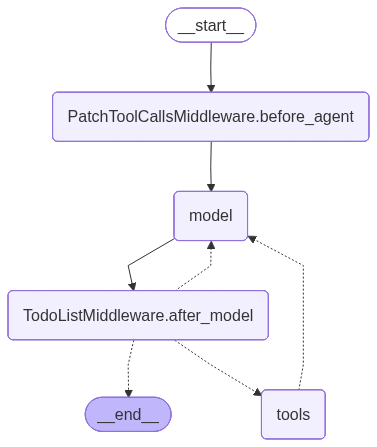

In [10]:
from deepagents import AsyncSubAgent, create_deep_agent

async_subagents = [
    AsyncSubAgent(
        name="researcher",
        description="Research agent for information gathering and synthesis",
        graph_id="researcher",
        # No url → ASGI transport (co-deployed in the same deployment)
    ),
    AsyncSubAgent(
        name="coder",
        description="Coding agent for code generation and review",
        graph_id="coder",
        # url="https://coder-deployment.langsmith.dev"  # Optional: HTTP transport for remote
    ),
]

# agent = create_deep_agent(
#     model=model,
#     subagents=async_subagents,
# )


agent = create_deep_agent(
    model=model,
    system_prompt="""...your instructions...

    After launching an async subagent, ALWAYS return control to the user.
    Never call check_async_task immediately after launch.""",
    subagents=async_subagents,
)

agent

### The AsyncSubAgentMiddleware which is included in the default middleware stack when async subagents are configured, gives the supervisor five tools:

![tools](assets/async_subagent_tools.png)




The supervisor’s LLM calls these tools like any other tool. The middleware handles thread creation, run management, and state persistence automatically.

## Simple invocation of agent:

In [12]:
import uuid

# 1. Create a unique session ID for the conversation memory
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

# 2. Send the message
inputs = {"messages": [("user", "Can you research the history of LangChain?")]}
response = await agent.ainvoke(inputs, config=config)

# 3. Print the final response
print(response["messages"][-1].content)

Failed to launch async subagent 'researcher': 'NoneType' object is not callable


CancelledError: 

## Streaming agent output(Seeing the tools run):

## A Complete Terminal Chat Loop